In [1]:
from visibilities import *
from images import *
import matplotlib.pyplot as plt
import matplotlib
import numpy
import helpers
from astropy.io import fits

plt.set_loglevel("critical")
cmap='turbo'
matplotlib.rcParams['figure.figsize'] = [6, 5]

create_named_configuration: MEERKAT
	(<Quantity 5109360.08350152 m>, <Quantity 2006852.56658911 m>, <Quantity -3238948.21751511 m>)
	GeodeticLocation(lon=<Longitude 21.44388889 deg>, lat=<Latitude -30.7110565 deg>, height=<Quantity 1086.6 m>)
create_configuration_from_file: 64 antennas/stations
create_visibility: created 120 times
create_visibility: 249600 rows, 0.013 GB
There is no flagged visibility. Skip plotting flagged.


/home/sunwang/.local/lib/python3.10/site-packages/ska_sdp_datamodels/visibility/vis_model.py:87: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'baselines' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  super().__init__(data_vars, coords=coords, attrs=attrs)


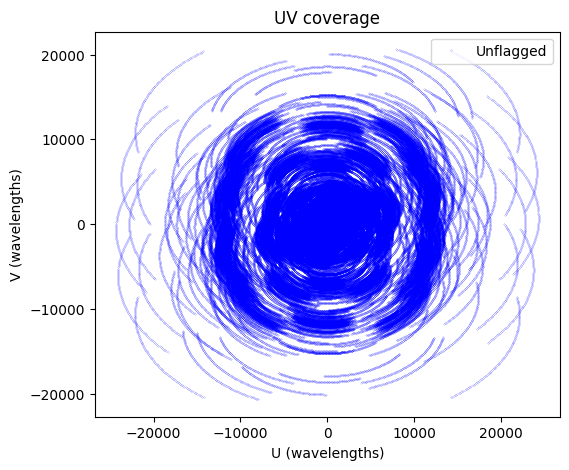

In [2]:
phasecentre = SkyCoord(ra=+56.0 * u.deg, dec=-35.0 * u.deg, frame='icrs', equinox='J2000')
ha_interval=(-2,2)
vt = generate_visibilities(phasecentre,ha_interval,tel="MEERKAT", integration_time=120, frequencies=np.array([1.e9]))
plot_uvcoverage([vt])

In [3]:
div = 1

npixels=512//div

dirac = numpy.zeros((npixels, npixels))
dirac[npixels//2, npixels//2] = 1

#dirac = helpers.shift_img(dirac, -0.5, -0.5)

dirac_fits = fits.PrimaryHDU(dirac)
orig = fits.open("../data/SGRA_full_gt.fits")[0]
dirac_fits.header = orig.header

hdulist = fits.HDUList([dirac_fits])
hdulist.writeto("../data/dirac.fits", overwrite=True)
hdulist.close()

to_rascil_format("../data/dirac.fits",postfix='')

This is a regular 2D image. Will be transformed into a RASCIL 4D image


advise_wide_field: (max_wavelength) Maximum wavelength 0.300 (meters)
advise_wide_field: (min_wavelength) Minimum wavelength 0.300 (meters)
advise_wide_field: (maximum_baseline) Maximum baseline 24331.5 (wavelengths)
advise_wide_field: (maximum_w) Maximum w 10775.0 (wavelengths)
advise_wide_field: (diameter) Station/dish diameter 13.5 (meters)
advise_wide_field: (primary_beam_fov) Primary beam 0.0222 (rad) 1.27 (deg) 4.58e+03 (asec)
advise_wide_field: (image_fov) Image field of view 0.0666 (rad) 3.82 (deg) 1.37e+04 (asec)
advise_wide_field: (synthesized_beam) Synthesized beam 4.11e-05 (rad) 0.00235 (deg) 8.48 (asec)
advise_wide_field: (cellsize) Cellsize 1.03e-05 (rad) 0.000589 (deg) 2.12 (asec)
advice_wide_field: (npixels) Npixels per side = 6484
advice_wide_field: (npixels2) Npixels (power of 2) per side = 8192
advice_wide_field: (npixels23) Npixels (power of 2, 3) per side = 8192
advice_wide_field: (npixels_min) Npixels (power of 2, 3, 4, 5) per side = 6500

advice_wide_field: (w_sa

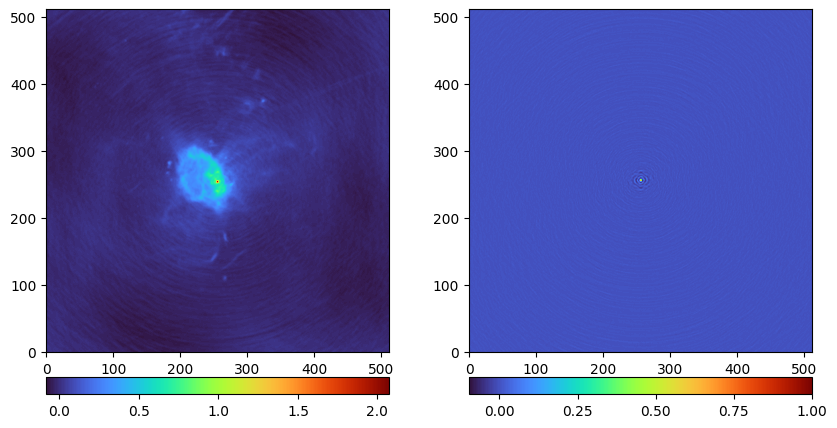

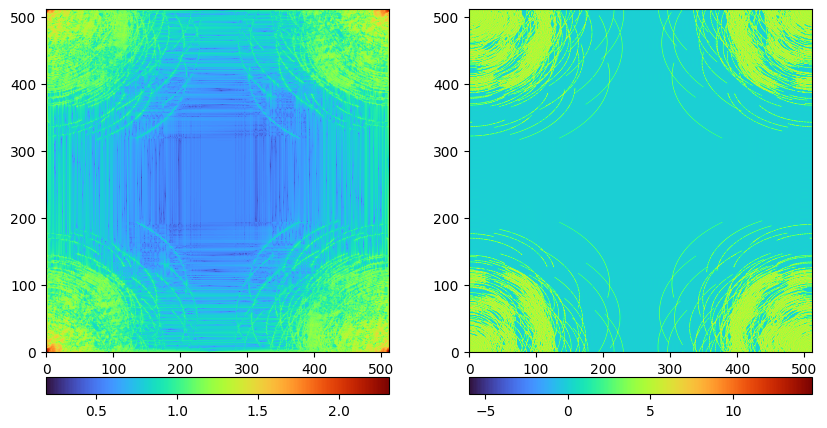

Dirty sym: 23.573965770918488
PSF sym: 2.6769495357004898
Dirty and psf diff: 34.749253944177134
fdirty - fdirty mirrored conjugate: 11653.86633279832


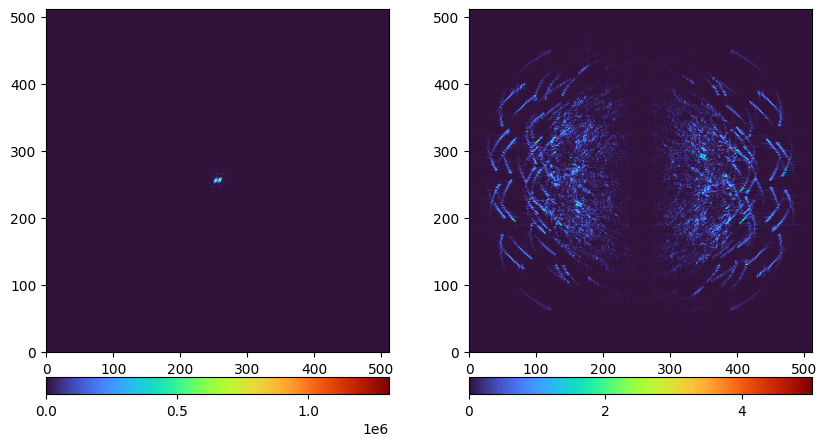

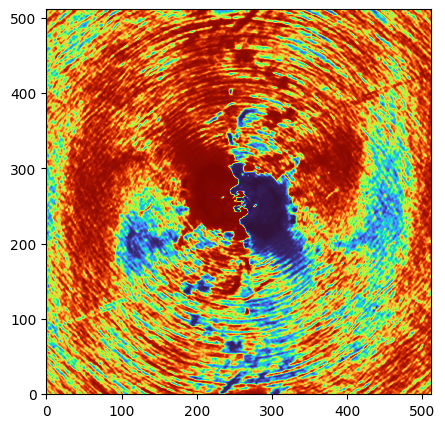

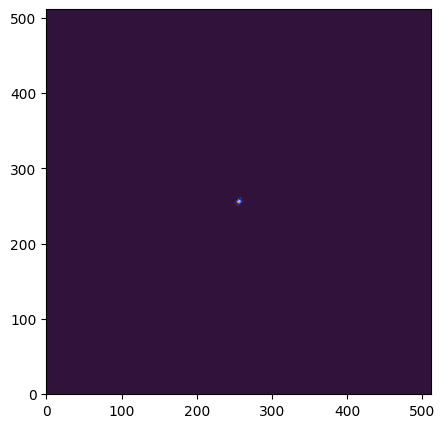

In [4]:
matplotlib.rcParams['figure.figsize'] = [10, 5]

vt, cell_size, im = visibilities_from_image(vt,'../data/SGRA_full_gt.fits',return_cellsize=True,return_image=True,scale_factor=1.8)

dirty, psf = dirty_psf_from_visibilities(vt,cell_size*div,npix=npixels,weighting="uniform")

dirty_np = dirty.pixels.data[0, 0,:,:]
psf_np = psf.pixels.data[0, 0,:,:]

helpers.plotNImages([dirty_np, \
                     psf_np], ["", ""], cmap=cmap)

helpers.write_nparr_to_fits(dirty_np, "../data/dirac_dirty.fits")
helpers.write_nparr_to_fits(dirty_np, "../data/test_psf.fits")

fdirty_np = numpy.fft.fft2(numpy.fft.ifftshift(dirty_np))
fpsf_np = numpy.fft.fft2(numpy.fft.ifftshift(psf_np))

helpers.plotNImages([np.abs(fdirty_np.real)**0.1, \
                     fpsf_np.real], ["", ""], cmap=cmap)

dirty_symcoeff = numpy.linalg.norm(dirty_np - dirty_np[::-1, ::-1])
psf_symcoeff = numpy.linalg.norm(psf_np - psf_np[::-1, ::-1])

print("Dirty sym: " + str(dirty_symcoeff))
print("PSF sym: " + str(psf_symcoeff))

print("Dirty and psf diff: " + str(numpy.linalg.norm(dirty_np - psf_np)))

fdiff = numpy.fft.fftshift(fdirty_np - fdirty_np[::-1, ::-1].conj())
print("fdirty - fdirty mirrored conjugate: " + str(numpy.linalg.norm(fdiff)))

helpers.plotNImages([numpy.imag(numpy.fft.fftshift(fdirty_np)) ** 2, \
                     numpy.imag(numpy.fft.fftshift(fpsf_np)) ** 2], ["", ""], cmap=cmap)

helpers.plotNImages([helpers.image_histogram_equalization(dirty_np - dirty_np[::-1, ::-1])], [""], cmap=cmap)
helpers.plotNImages([np.abs(fdiff) ** 2], [""], cmap=cmap)



Times, serial-parallel: 9.152011156082153 : 30.535870790481567


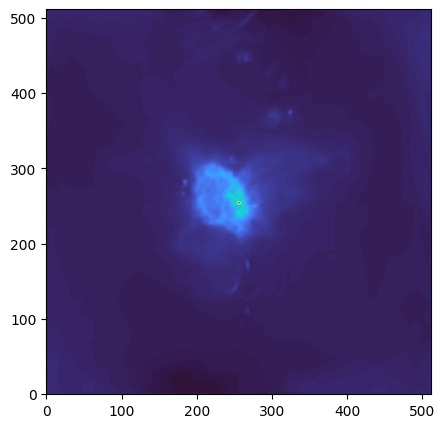

In [5]:
import sys
import pywt
import time

sys.path.insert(1, '../fista-python/')

import fista
from fista import Filter2D

wavelets=[pywt.Wavelet('db1'), pywt.Wavelet('db2'), pywt.Wavelet('db3'), pywt.Wavelet('db4'), pywt.Wavelet('db5'), \
         pywt.Wavelet('db6'), pywt.Wavelet('db7'), pywt.Wavelet('db8')]

psf_fista = Filter2D(psf_np)

start_serial = time.time()
deconvolved = fista.fista(psf_fista, dirty_np, 0.002, wavelets, 100,parallelize_wavelets=False)
end_serial=time.time()

start_parallel = time.time()
deconvolved = fista.fista(psf_fista, dirty_np, 0.002, wavelets, 100,parallelize_wavelets=True)
end_parallel=time.time()

print("Times, serial-parallel: " + str(end_serial-start_serial) + " : " + str(end_parallel-start_parallel))

helpers.plotNImages([deconvolved], [""], cmap=cmap)